# XGBoost Per-Participant Drowsiness Predictions

Loads processed data from `Processed_Participants_Data/`, trains XGBoost per participant (Stratified K-Fold CV), and saves predictions back to the CSVs.

---

## Methodology Report

### 1 — Input Features (8 signals, no HR/HRV)

| Feature | Type | Description |
|---|---|---|
| `perclos` | Visual | % of time eyes are closed — primary drowsiness indicator |
| `eye_blink_rate` | Visual | Blinks per minute; high = fatigue, very low = fixed stare |
| `blink_duration_mean` | Visual | Average blink duration (s); >0.15 s suggests eyelid fatigue |
| `blink_duration_max` | Visual | Longest blink in window; large values indicate partial eye closure events |
| `yawning_rate` | Behavioral | Yawns per minute; even 1/min is meaningful |
| `std_lane_position` | Driving | Std dev of lateral position (m); higher = worse lane-keeping |
| `steering_entropy` | Driving | Complexity of steering inputs; very low = passive/monotonous driving |
| `steering_reversal_rate` | Driving | Steering direction changes per sec; declining rate signals fatigue |

**Labels (Wierwille Sleepiness Scale → 3 classes):**
- `1 = Low` (WSS 1–2) · `2 = Moderate` (WSS 3 – partial 4) · `3 = High` (WSS partial 4–5)

---

### 2 — Preprocessing Pipeline

```
Raw features (8)
    │
    ▼
StandardScaler          ← zero-mean, unit-variance per feature
    │
    ▼
PCA (90 % variance)     ← reduces dimensionality, removes correlated features
    │                      typically reduces to 3–5 components
    ▼
XGBoost classifier      ← n_estimators=150, max_depth=4, lr=0.05
                           subsample=0.8, colsample_bytree=0.8
```

---

### 3 — Split Strategy: Why Sequential Order Matters

Each participant's data is a **temporal sequence** of driving windows (window 1 → 2 → … → N).  
Using random K-Fold (StratifiedKFold) on this data causes **temporal leakage** — the model can train on *future* windows and test on *past* ones, which overestimates real-world performance.

**Correct approach → `TimeSeriesSplit`:**
- Always trains on the **past**, tests on the **future**
- Mirrors real deployment: the model only knows what happened before the current window
- Each fold expands the training set chronologically (expanding window evaluation)

```
Fold 1:  [train: 1–10]  [test: 11–12]
Fold 2:  [train: 1–20]  [test: 21–22]
Fold 3:  [train: 1–30]  [test: 31–32]
...
```

**Trade-off:** Early folds have very little training data — accuracy may be lower than random K-Fold, but it is *honest* about how well the model generalises to unseen future windows.

---

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print('Imports OK')

Imports OK


In [2]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
PROCESSED_DIR = '/home/karthik/Desktop/llm_eval/Processed_Participants_Data'

FEATURES = [
    'perclos',
    'eye_blink_rate',
    'blink_duration_mean',
    'blink_duration_max',
    'yawning_rate',
    'std_lane_position',
    'steering_entropy',
    'steering_reversal_rate',
]

PCA_VARIANCE = 0.90
N_SPLITS     = 5
RANDOM_STATE = 42

In [ ]:
# ── PCA + XGBOOST — TIME-SERIES SPLIT (SEQUENTIAL) ────────────────────────
#
# Data is sorted by window_id (temporal order) before splitting.
# TimeSeriesSplit trains only on past windows and tests on future ones,
# avoiding temporal leakage from random K-Fold.
#
from sklearn.model_selection import TimeSeriesSplit

results = {}   # pid → dict

for pid, (csv_path, df) in data.items():
    # ── Sort by window_id to preserve temporal order ──────────────────────
    if 'window_id' in df.columns:
        df = df.sort_values('window_id').reset_index(drop=True)

    df = df.dropna(subset=FEATURES + ['drowsiness_level']).reset_index(drop=True)

    X = df[FEATURES].values
    y = df['drowsiness_level'].values - 1   # 0-indexed

    # ── PCA ───────────────────────────────────────────────────────────────
    scaler   = StandardScaler()
    X_s      = scaler.fit_transform(X)
    cumvar   = np.cumsum(PCA(random_state=RANDOM_STATE).fit(X_s).explained_variance_ratio_)
    n_comp   = max(2, int(np.searchsorted(cumvar, PCA_VARIANCE)) + 1)
    pca      = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_pca    = pca.fit_transform(X_s)

    # ── TimeSeriesSplit — respects temporal order ─────────────────────────
    # Minimum ~6 samples needed in each test fold; use fewer splits for small datasets
    n_splits = min(N_SPLITS, max(2, len(df) // 10))
    tscv     = TimeSeriesSplit(n_splits=n_splits)

    clf = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        verbosity=0,
    )

    fold_accs = []
    y_pred_all = np.full_like(y, -1)

    for tr_idx, te_idx in tscv.split(X_pca):
        clf.fit(X_pca[tr_idx], y[tr_idx])
        y_hat = clf.predict(X_pca[te_idx])
        fold_accs.append(accuracy_score(y[te_idx], y_hat))
        y_pred_all[te_idx] = y_hat

    # Only evaluate on windows that appeared in at least one test fold
    eval_mask = y_pred_all >= 0
    y_eval    = y[eval_mask] + 1
    p_eval    = y_pred_all[eval_mask] + 1

    results[pid] = {
        'df':       df,
        'csv_path': csv_path,
        'y_true':   y_eval,
        'y_pred':   p_eval,
        'acc':      np.mean(fold_accs),
        'std':      np.std(fold_accs),
        'f1_macro': f1_score(y_eval, p_eval, average='macro', zero_division=0),
        'n_comp':   n_comp,
        'n_splits': n_splits,
        'n_eval':   eval_mask.sum(),
    }

print('Split strategy: TimeSeriesSplit (train on past → test on future)\n')
print(f'{"Participant":<12} {"Accuracy":>9} {"±":>5} {"F1-macro":>9}  {"PCs":>4}  {"Splits":>6}  {"Eval windows"}')
print('-' * 62)
for pid, r in results.items():
    print(f'{pid:<12} {r["acc"]:>9.3f} {r["std"]:>5.3f} {r["f1_macro"]:>9.3f}  {r["n_comp"]:>4}  {r["n_splits"]:>6}  {r["n_eval"]}/{len(data[pid][1])}')
print('-' * 62)
mean_acc = np.mean([r['acc'] for r in results.values()])
mean_f1  = np.mean([r['f1_macro'] for r in results.values()])
print(f'{"Mean":<12} {mean_acc:>9.3f} {"":>5} {mean_f1:>9.3f}')

In [4]:
# ── PCA + XGBOOST CV PER PARTICIPANT ──────────────────────────────────────
results = {}   # pid → dict

for pid, (csv_path, df) in data.items():
    df = df.dropna(subset=FEATURES + ['drowsiness_level']).reset_index(drop=True)

    X = df[FEATURES].values
    y = df['drowsiness_level'].values - 1   # 0-indexed

    # PCA
    X_s   = StandardScaler().fit_transform(X)
    cumvar = np.cumsum(PCA(random_state=RANDOM_STATE).fit(X_s).explained_variance_ratio_)
    n_comp = max(2, int(np.searchsorted(cumvar, PCA_VARIANCE)) + 1)
    X_pca  = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit_transform(X_s)

    # Adaptive folds (can't have more folds than smallest class)
    k    = min(N_SPLITS, int(pd.Series(y).value_counts().min()))
    cv   = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

    clf = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        verbosity=0,
    )

    scores = cross_val_score(clf, X_pca, y, cv=cv, scoring='accuracy')

    y_pred = np.zeros_like(y)
    for tr, te in cv.split(X_pca, y):
        clf.fit(X_pca[tr], y[tr])
        y_pred[te] = clf.predict(X_pca[te])

    results[pid] = {
        'df':       df,
        'csv_path': csv_path,
        'y_true':   y + 1,
        'y_pred':   y_pred + 1,
        'acc':      scores.mean(),
        'std':      scores.std(),
        'f1_macro': f1_score(y + 1, y_pred + 1, average='macro', zero_division=0),
        'n_comp':   n_comp,
    }

print(f'{"Participant":<12} {"Accuracy":>9} {"±":>4} {"F1-macro":>9}  {"PCs"}')
print('-' * 45)
for pid, r in results.items():
    print(f'{pid:<12} {r["acc"]:>9.3f} {r["std"]:>4.3f} {r["f1_macro"]:>9.3f}  {r["n_comp"]}')
print('-' * 45)
mean_acc = np.mean([r['acc'] for r in results.values()])
mean_f1  = np.mean([r['f1_macro'] for r in results.values()])
print(f'{"Mean":<12} {mean_acc:>9.3f} {" ":>4} {mean_f1:>9.3f}')

Participant   Accuracy    ±  F1-macro  PCs
---------------------------------------------
01_V             0.946 0.018     0.609  4
02_MK            0.742 0.100     0.743  4
03_A             0.667 0.033     0.451  4
04_SB            0.738 0.173     0.744  4
05_TG            0.657 0.083     0.655  5
06_MV            0.764 0.178     0.684  5
07_GK            1.000 0.000     1.000  3
08_D             0.950 0.000     0.487  5
---------------------------------------------
Mean             0.808          0.672


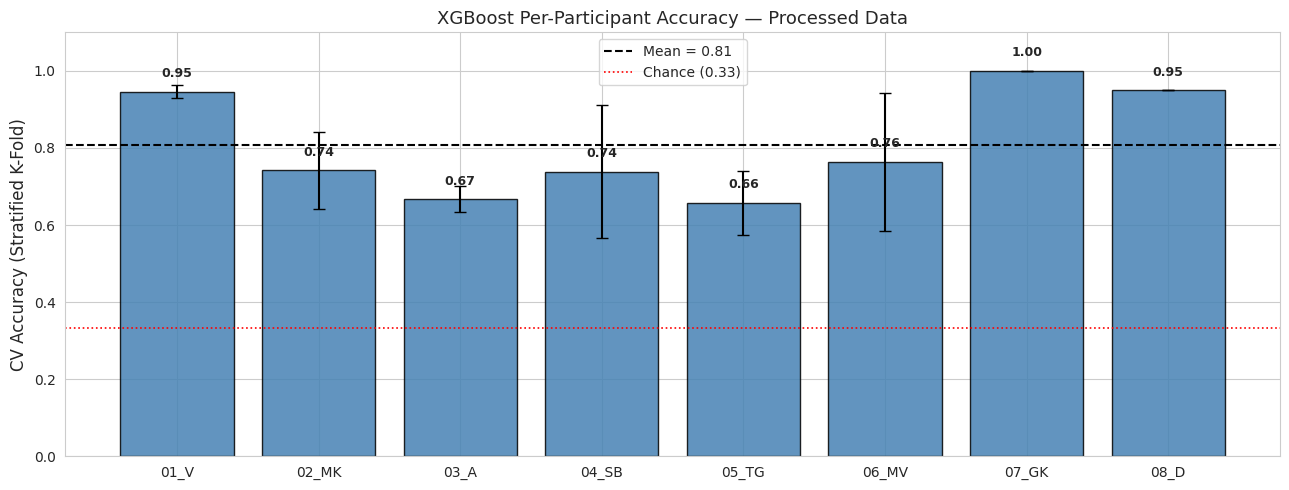

In [5]:
# ── ACCURACY BAR CHART ────────────────────────────────────────────────────
pids  = list(results.keys())
accs  = [results[p]['acc'] for p in pids]
stds  = [results[p]['std'] for p in pids]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(pids, accs, yerr=stds, capsize=4, color='steelblue', alpha=0.85, edgecolor='black')
ax.axhline(mean_acc, color='black', linestyle='--', linewidth=1.5, label=f'Mean = {mean_acc:.2f}')
ax.axhline(0.333,    color='red',   linestyle=':',  linewidth=1.2, label='Chance (0.33)')
ax.set_ylabel('CV Accuracy (Stratified K-Fold)', fontsize=12)
ax.set_title('XGBoost Per-Participant Accuracy — Processed Data', fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

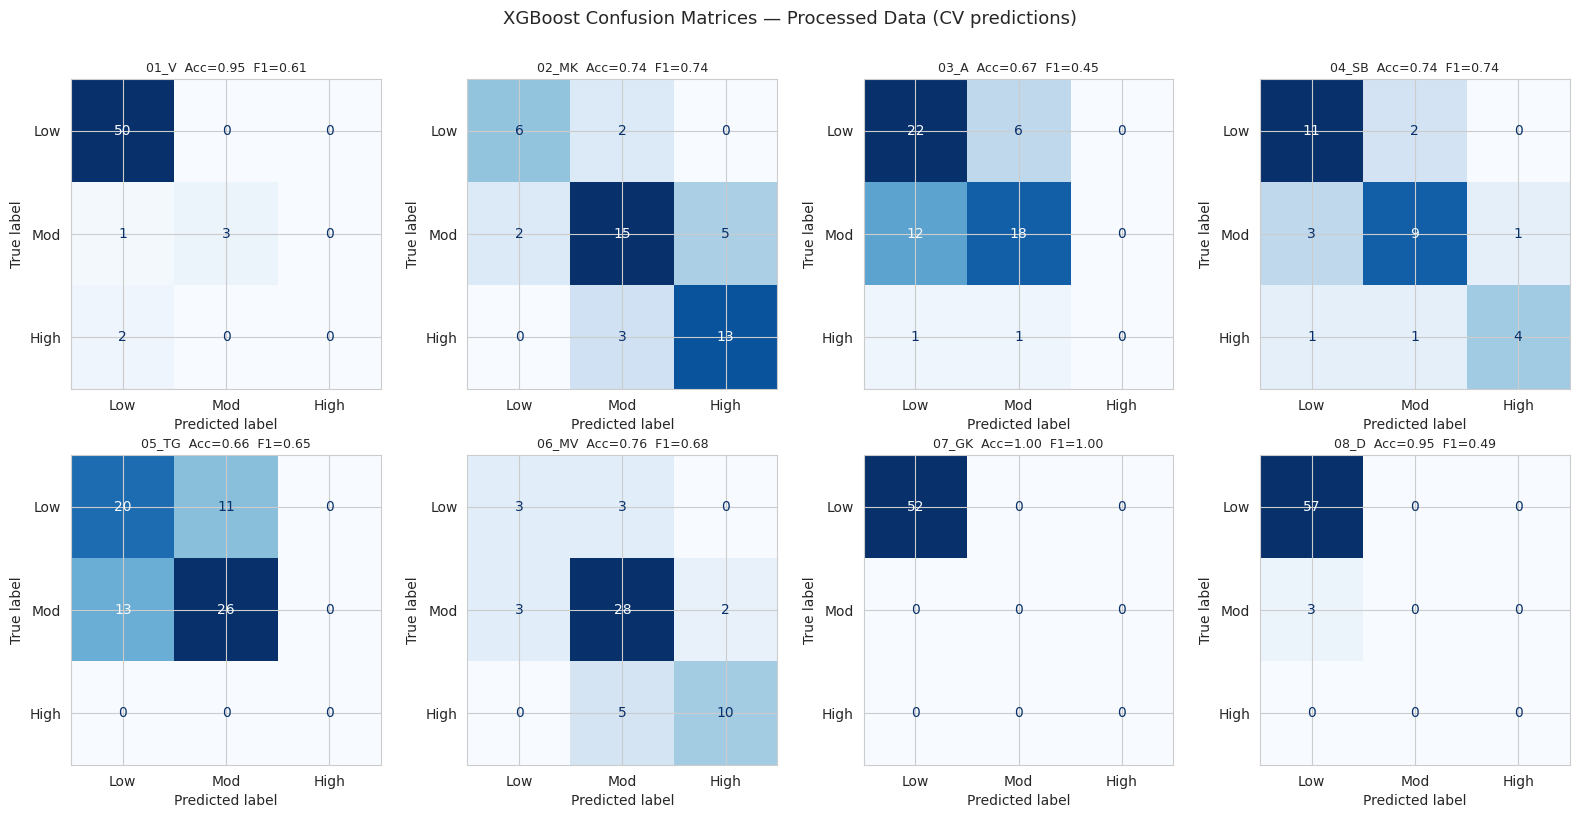

In [6]:
# ── CONFUSION MATRICES ────────────────────────────────────────────────────
n_cols = 4
n_rows = (len(pids) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, pid in enumerate(pids):
    r  = results[pid]
    cm = confusion_matrix(r['y_true'], r['y_pred'], labels=[1, 2, 3])
    ConfusionMatrixDisplay(cm, display_labels=['Low', 'Mod', 'High']).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(f'{pid}  Acc={r["acc"]:.2f}  F1={r["f1_macro"]:.2f}', fontsize=9)

for ax in axes[len(pids):]:
    ax.set_visible(False)

plt.suptitle('XGBoost Confusion Matrices — Processed Data (CV predictions)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# ── CLASSIFICATION REPORTS ─────────────────────────────────────────────────
LABEL_NAMES = {1: 'Low', 2: 'Moderate', 3: 'High'}

for pid, r in results.items():
    print(f'=== {pid} ===')
    present_labels = sorted(set(r['y_true']) | set(r['y_pred']))
    target_names   = [LABEL_NAMES[l] for l in present_labels]
    print(classification_report(r['y_true'], r['y_pred'],
                                labels=present_labels,
                                target_names=target_names,
                                zero_division=0))

=== 01_V ===
              precision    recall  f1-score   support

         Low       0.94      1.00      0.97        50
    Moderate       1.00      0.75      0.86         4
        High       0.00      0.00      0.00         2

    accuracy                           0.95        56
   macro avg       0.65      0.58      0.61        56
weighted avg       0.91      0.95      0.93        56

=== 02_MK ===
              precision    recall  f1-score   support

         Low       0.75      0.75      0.75         8
    Moderate       0.75      0.68      0.71        22
        High       0.72      0.81      0.76        16

    accuracy                           0.74        46
   macro avg       0.74      0.75      0.74        46
weighted avg       0.74      0.74      0.74        46

=== 03_A ===
              precision    recall  f1-score   support

         Low       0.63      0.79      0.70        28
    Moderate       0.72      0.60      0.65        30
        High       0.00      0.00  

In [9]:
# ── SAVE PREDICTIONS BACK TO PROCESSED CSVs ───────────────────────────────
for pid, r in results.items():
    df_out   = pd.read_csv(r['csv_path'])
    df_clean = df_out.dropna(subset=FEATURES + ['drowsiness_level'])
    df_out.loc[df_clean.index, 'xgb_predicted_label'] = r['y_pred']
    df_out.to_csv(r['csv_path'], index=False)
    print(f'  {pid}: saved {len(r["y_pred"])} predictions → {r["csv_path"]}')

print('\nAll processed CSVs updated with xgb_predicted_label column.')

  01_V: saved 56 predictions → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/01_V_Processed/V_processed.csv
  02_MK: saved 46 predictions → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/02_MK_Processed/MK_processed.csv
  03_A: saved 60 predictions → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/03_A_Processed/A_processed.csv
  04_SB: saved 32 predictions → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/04_SB_Processed/SB_processed.csv
  05_TG: saved 70 predictions → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/05_TG_Processed/TG_processed.csv
  06_MV: saved 54 predictions → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/06_MV_Processed/MV_processed.csv
  07_GK: saved 52 predictions → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/07_GK_Processed/GK_processed.csv
  08_D: saved 60 predictions → /home/karthik/Desktop/llm_eval/Processed_Participants_Data/08_D_Processed/D_processed.csv

All processed CS